In [57]:
import os
import matplotlib.pyplot as plt

dir = '/nfs/disk1/users/bharris/SN_stuff/snowglobes/out/' 
flux = 'sns_20m'
detector = 'eos'
smear = ''


dat_filenames = [
    flux+'_nue_O16_'+detector+'_events'+smear+'.dat',
    flux+'_nue_O16_2_'+detector+'_events'+smear+'.dat',
    flux+'_nue_O16_Suzuki2018_'+detector+'_events'+smear+'.dat',
    flux+'_nue_O16_Newton_'+detector+'_events'+smear+'.dat',
    flux+'_nc_nue_O16_'+detector+'_events'+smear+'.dat',
    flux+'_nc_numu_O16_'+detector+'_events'+smear+'.dat',
    flux+'_nc_numubar_O16_'+detector+'_events'+smear+'.dat',
    flux+'_nue_e_'+detector+'_events'+smear+'.dat',
    flux+'_numu_e_'+detector+'_events'+smear+'.dat',
    flux+'_numubar_e_'+detector+'_events'+smear+'.dat',
    # flux+'_nue_C12_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_nue_C12_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_numu_C12_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_numubar_C12_'+detector+'_events'+smear+'.dat',
    # flux+'_nue_C13_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_nue_C13_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_numu_C13_'+detector+'_events'+smear+'.dat',
    # flux+'_nc_numubar_C13_'+detector+'_events'+smear+'.dat',
]

# Example: compare three O16 nu_e models
labels = [
    r"CC $\nu_{e}$ $^{16}O$ (Kolbe 2002)",
    r"CC $\nu_{e}$ $^{16}O$ (Unkn.)",
    r"CC $\nu_{e}$ $^{16}O$ (Suzuki 2018)",
    r"CC $\nu_{e}$ $^{16}O$ (Nakazato 2022)",
    r"NC $\nu_{e}$ $^{16}O$",
    r"NC $\nu_{\mu}$ $^{16}O$",
    r"NC $\nu_{\overline{\mu}}$ $^{16}O$",
    r"$\nu_{e}$ eES",
    r"$\nu_{\mu}$ eES",
    r"$\nu_{\overline{\mu}}$ eES",
    r"CC $\nu_{e}$ $^{12}C$",
    r"NC $\nu_{e}$ $^{12}C$",
    r"NC $\nu_{\mu}$ $^{12}C$",
    r"NC $\nu_{\overline{\mu}}$ $^{12}C$",
    r"CC $\nu_{e}$ $^{13}C$",
    r"NC $\nu_{e}$ $^{13}C$",
    r"NC $\nu_{\mu}$ $^{13}C$",
    r"NC $\nu_{\overline{\mu}}$ $^{13}C$",
]


flavors = [
    "nue",
    "nue",
    "nue",
    "nue",
    "nue",
    "numu",
    "numubar",
    "nue",
    "numu",
    "numubar",
    "nue",
    "nue",
    "numu",
    "numubar",
    "nue",
    "nue",
    "numu",
    "numubar",
]

colors = [
    "dodgerblue",
    "dodgerblue",
    "dodgerblue",
    "dodgerblue",
    "tomato",
    "tomato",
    "tomato",
    "orange",
    "orange",
    "orange",
    "limegreen",
    "limegreen",
    "limegreen",
    "limegreen",
    "mediumorchid",
    "mediumorchid",
    "mediumorchid",


]

linestyles = [
    "-",
    "--",
    "-.",
    ":",
    "-",
    "--",
    "-.",
    "-",
    "--",
    "-.",
    "-",
    "--",
    "-.",
    ":",
    "-",
    "--",
    "-.",
    ":",
]

FACTOR = 5000 * 3600  # seconds per SNS year

def channel_from_path(path, flux=flux, detector=detector):

    name = os.path.splitext(os.path.basename(path))[0]

    # Drop event suffixes
    for suffix in (
        '_events_smeared_unweighted',
        '_events_smeared',
        '_events_unweighted',
        '_events',
    ):
        if name.endswith(suffix):
            name = name[:-len(suffix)]
            break

    # Remove flux prefix like "sns_ppu_20m_"
    if flux and name.startswith(flux + '_'):
        name = name[len(flux) + 1 :]

    # Remove detector suffix like "eos" or "_eos"
    if detector:
        if name.endswith('_' + detector):
            name = name[: -len(detector) - 1]
        elif name.endswith(detector):
            name = name[: -len(detector)]

    return name

def get_total_from_file(path):
    """Read file and return the total (from 'Total:' line)."""
    with open(path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    if not lines:
        return 0.0
    last = lines[-1]
    if last.lower().startswith('total:'):
        for p in last.split()[1:]:
            try:
                return float(p)
            except ValueError:
                continue
    # fallback: last data line, second column
    for p in reversed(last.split()):
        try:
            return float(p)
        except ValueError:
            continue
    return 0.0

def read_xy(path):
    """Return (x_vals, y_vals) for plottable data lines (skip separator and Total)."""
    x_vals, y_vals = [], []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('-') or line.lower().startswith('total'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                x_vals.append(float(parts[0]))
                y_vals.append(float(parts[1]))
            except ValueError:
                continue
    return x_vals, y_vals

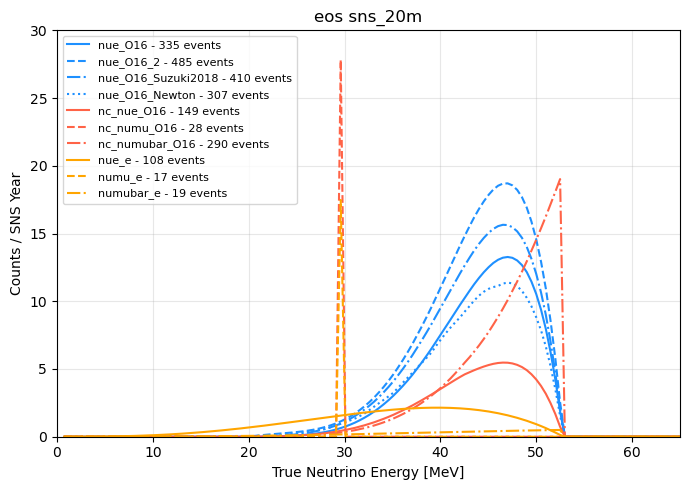

In [58]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Plot all files on the same axes; legend = channel + total events (× 5000×360)

plt.figure(figsize=(7, 5))
for file, label, color, ls in zip(dat_filenames, labels, colors, linestyles)   :
    path = dir+file
    x_vals, y_vals = read_xy(path)
    total = get_total_from_file(path)
    total_events = total * FACTOR
    channel = channel_from_path(path)
    label = f'{channel} - {total_events:,.0f} events'
    plt.plot(np.array(x_vals)*1e3, np.array(y_vals)*FACTOR, linestyle=ls, color=color, label=label)

plt.style.use("seaborn-v0_8-colorblind")
plt.title(detector+' '+flux)
plt.xlabel('True Neutrino Energy [MeV]')
plt.ylabel('Counts / SNS Year')
plt.xlim(0, 65)
plt.ylim(0,30)
# plt.ylim(1e-1, 1e2)
# plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()